## Analysis Dataset

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# dataset path
dataset_path = r'dataset'

data_set = os.listdir(dataset_path)

In [2]:
len(data_set)

47

# handle issue

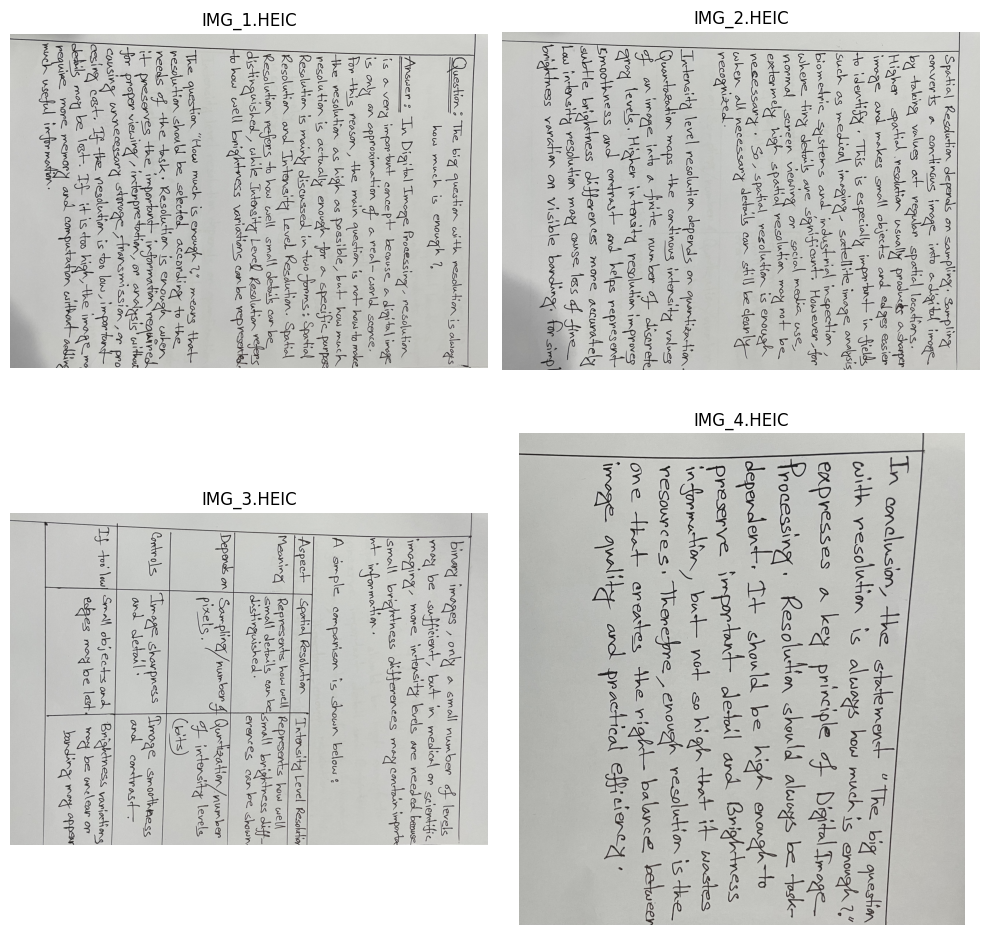

In [3]:
import warnings
import imageio
warnings.filterwarnings('ignore', category=DeprecationWarning)

folder = r'dataset\223311016'
images = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.png', '.heic'))]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for idx, img_name in enumerate(images[:4]):
    img = imageio.imread(os.path.join(folder, img_name))
    axes[idx].imshow(img)
    axes[idx].set_title(img_name)
    axes[idx].axis('off')

plt.tight_layout()
# plt.show()

# Mid-Level Image Processing

In [21]:
# Collect folders that contain images
folders_with_images = []

for folder_name in data_set:
    folder_path = os.path.join(dataset_path, folder_name)
    if os.path.isdir(folder_path):
        # Count image files in the folder
        img_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg', '.heic', '.gif', '.bmp'))]
        if img_files:
            folders_with_images.append(folder_name)

In [ ]:
folders_with_images

NameError: name 'folders_with_images' is not defined

Selected techniques: 5
Loaded 231 images from 46 folders


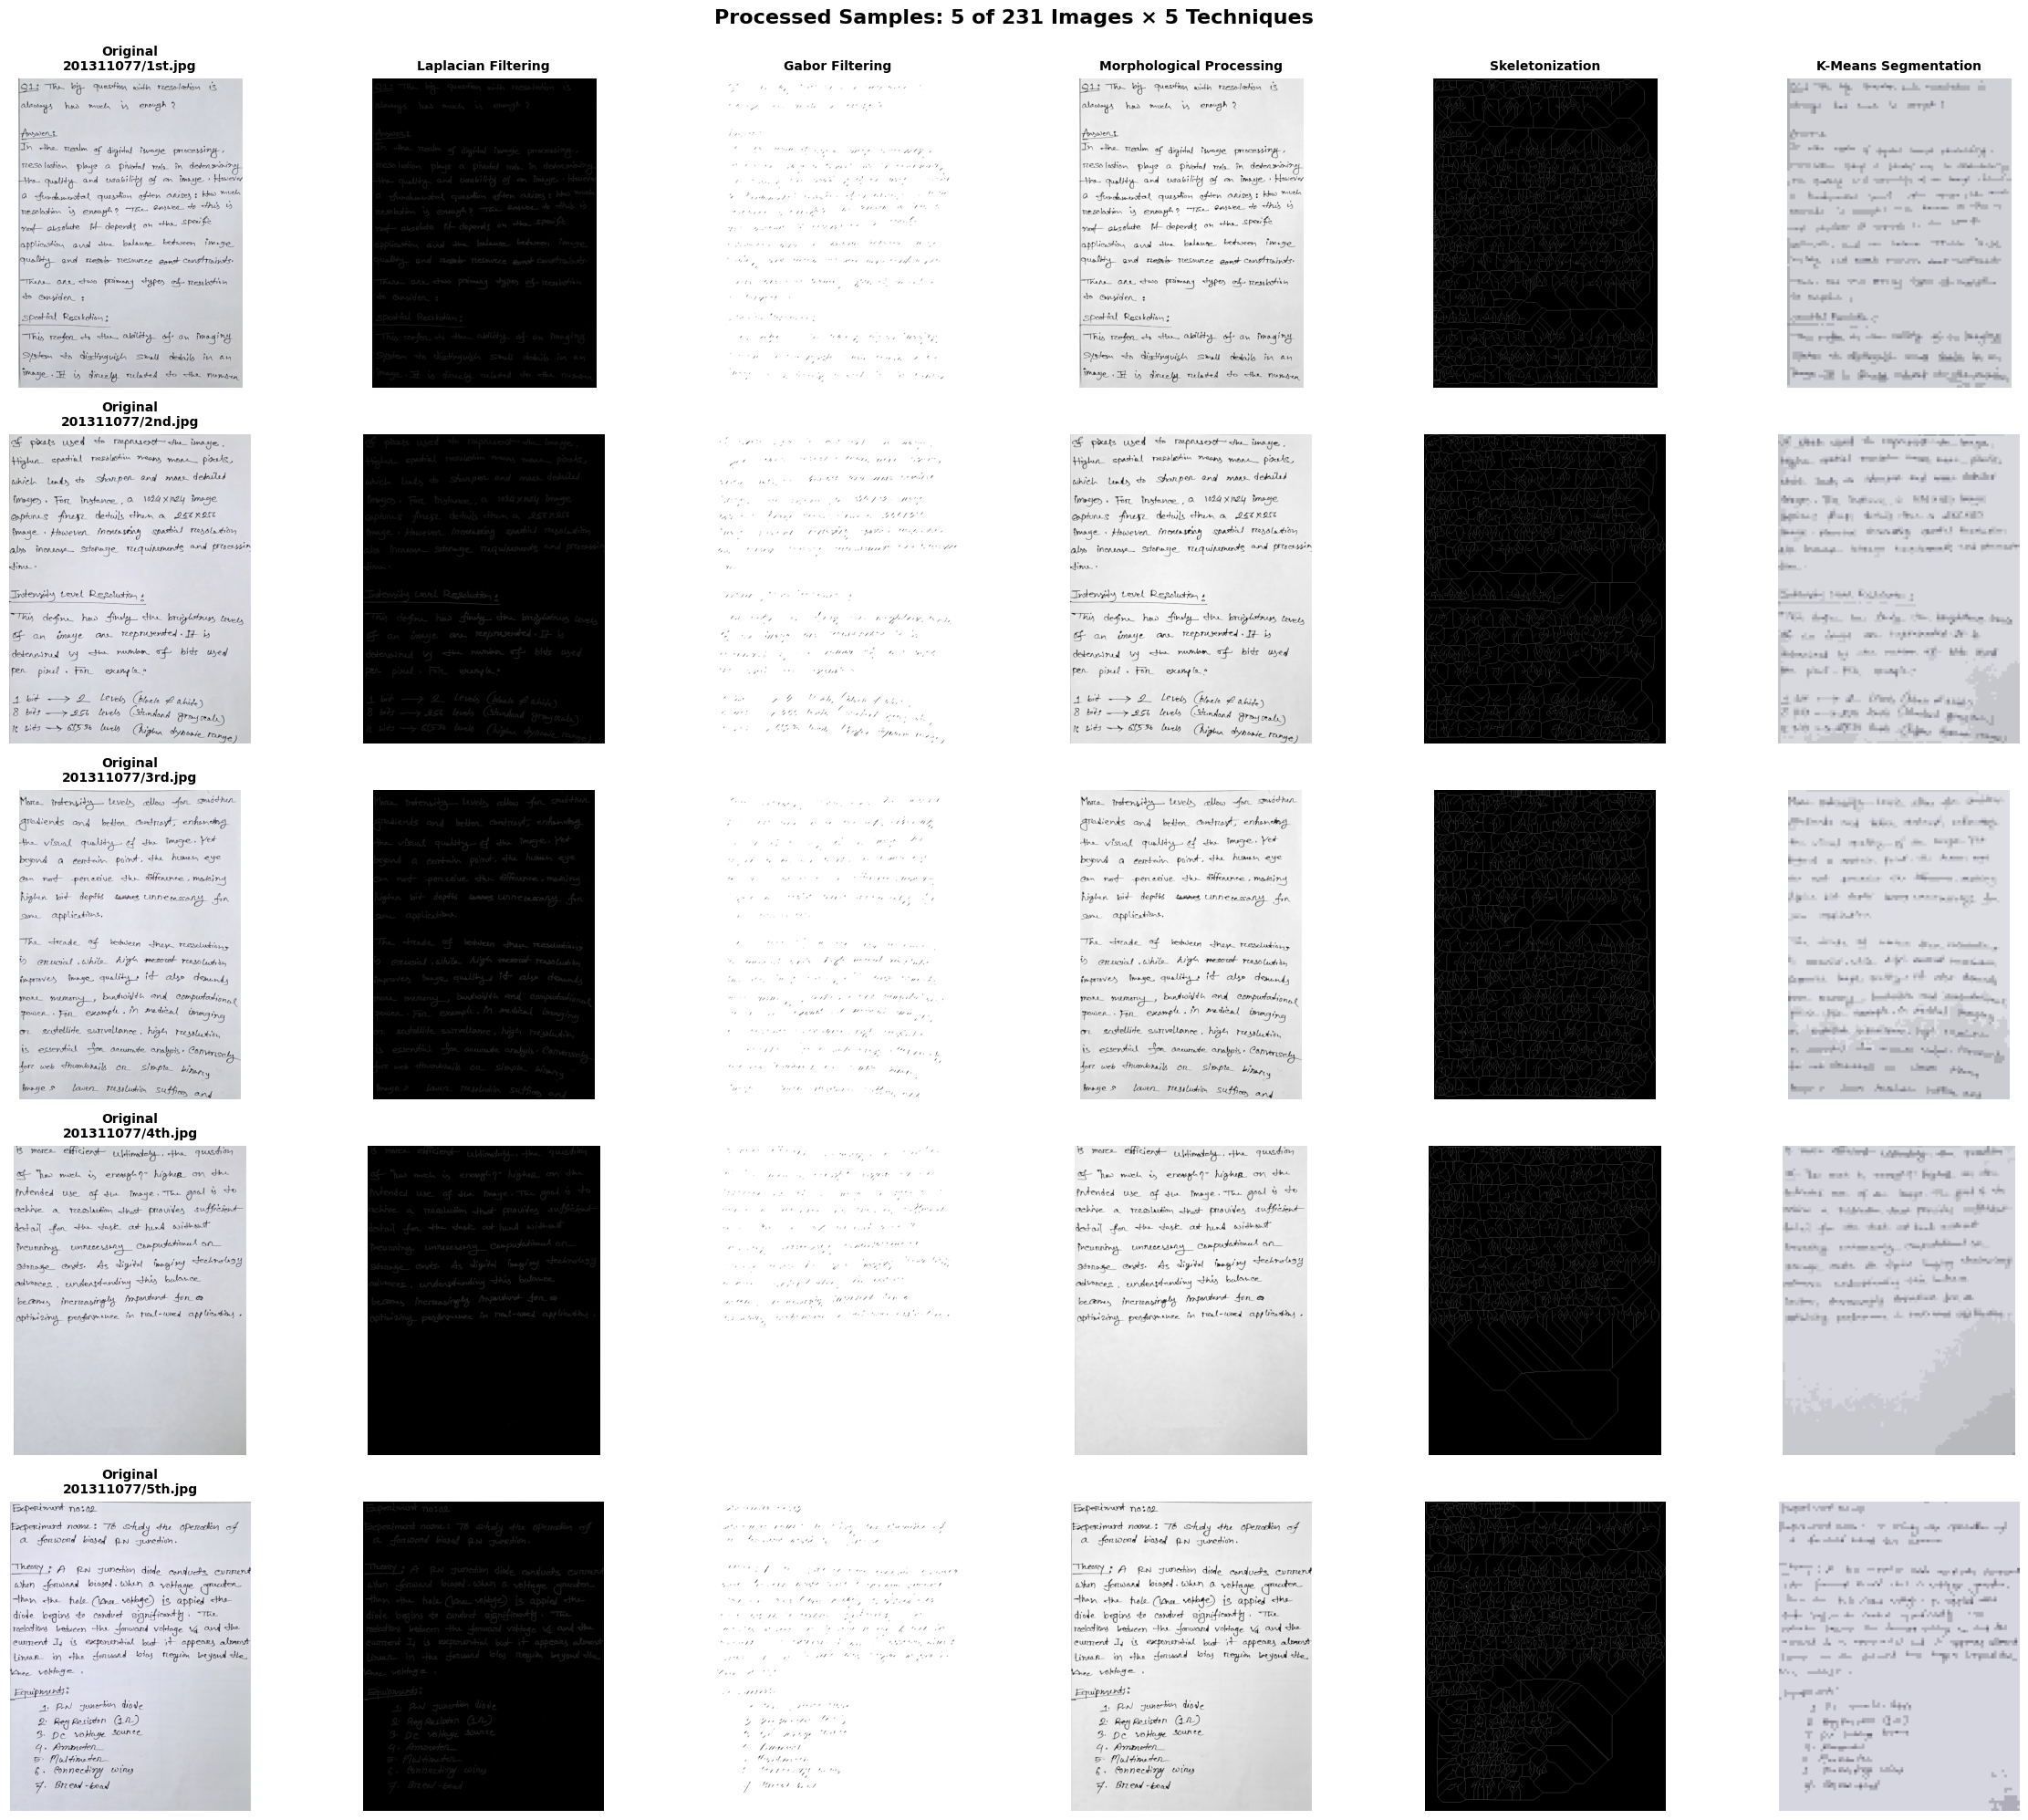

In [23]:
import cv2
from scipy import ndimage
from skimage import morphology, filters, feature, exposure, segmentation
from sklearn.cluster import KMeans

# Define all available techniques
available_techniques = {
    'Laplacian Filtering': 'laplacian',
    'Gabor Filtering': 'gabor',
    'Morphological Processing': 'morphological',
    'Skeletonization': 'skeletonization',
    'K-Means Segmentation': 'kmeans',
    'Histogram Equalization': 'histogram_eq',
    'Sharpening Filter': 'sharpening',
    'Gaussian Blur': 'gaussian_blur',
    'Canny Edge Detector': 'canny',
    'Sobel Operator': 'sobel'
}

# Students select 5 techniques
selected_techniques = ['Laplacian Filtering', 'Gabor Filtering', 'Morphological Processing', 
                       'Skeletonization', 'K-Means Segmentation']

# Function to apply each technique
def apply_laplacian(img):
    """Apply Laplacian filtering"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    laplacian = np.uint8(np.clip(laplacian, 0, 255))
    return laplacian

def apply_gabor(img):
    """Apply Gabor filtering"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getGaborKernel((21, 21), 3, np.pi/4, 10, 0.5, 0)
    filtered = cv2.filter2D(gray, -1, kernel)
    filtered = np.uint8(np.clip(filtered, 0, 255))
    return filtered

def apply_morphological(img):
    """Apply morphological processing (opening)"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    opened = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)
    return opened

def apply_skeletonization(img):
    """Apply skeletonization"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    skeleton = morphology.skeletonize(binary // 255)
    return np.uint8(skeleton * 255)

def apply_kmeans(img):
    """Apply K-Means segmentation"""
    max_dimension = 120
    height, width = img.shape[:2]
    if max(height, width) > max_dimension:
        scale = max_dimension / float(max(height, width))
        resized = cv2.resize(img, (int(width * scale), int(height * scale)), interpolation=cv2.INTER_AREA)
    else:
        resized = img

    data = resized.reshape((-1, 3))
    data = np.float32(data)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 5, 1.0)
    k = 4
    _, label, center = cv2.kmeans(data, k, None, criteria, 1, cv2.KMEANS_RANDOM_CENTERS)
    center = np.uint8(center)
    segmented = center[label.flatten()].reshape(resized.shape)

    if segmented.shape != img.shape:
        segmented = cv2.resize(segmented, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

    return segmented

# Map technique names to functions
technique_functions = {
    'Laplacian Filtering': apply_laplacian,
    'Gabor Filtering': apply_gabor,
    'Morphological Processing': apply_morphological,
    'Skeletonization': apply_skeletonization,
    'K-Means Segmentation': apply_kmeans
}

print(f"Selected techniques: {len(selected_techniques)}")

# Load all images from every folder in the dataset
original_images_list = []
image_names = []
image_folders = []

for folder_name in folders_with_images:
    folder_path = os.path.join(dataset_path, folder_name)
    img_files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg', '.heic', '.gif', '.bmp'))])
    
    for img_file in img_files:
        img_path = os.path.join(folder_path, img_file)
        img = cv2.imread(img_path)
        if img is not None:
            original_images_list.append(img)
            image_names.append(img_file)
            image_folders.append(folder_name)

if not original_images_list:
    raise ValueError('No images were loaded from the dataset.')

print(f'Loaded {len(original_images_list)} images from {len(folders_with_images)} folders')

# Display a sample of the full dataset in a dynamic grid
sample_size = min(5, len(original_images_list))
fig, axes = plt.subplots(sample_size, len(selected_techniques) + 1, figsize=(24, 4 * sample_size))
axes = np.atleast_2d(axes)

# For each sample image
for img_idx in range(sample_size):
    original_img = original_images_list[img_idx]
    # Show original image in first column
    original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    axes[img_idx, 0].imshow(original_img_rgb)
    axes[img_idx, 0].set_title(f'Original\n{image_folders[img_idx]}/{image_names[img_idx]}', fontweight='bold', fontsize=10)
    axes[img_idx, 0].axis('off')
    
    # Apply each technique to this image
    for tech_idx, technique_name in enumerate(selected_techniques):
        technique_func = technique_functions[technique_name]
        processed = technique_func(original_img)
        
        # Display processed image
        if len(processed.shape) == 3:  # Color image
            processed_rgb = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)
            axes[img_idx, tech_idx + 1].imshow(processed_rgb)
        else:  # Grayscale image
            axes[img_idx, tech_idx + 1].imshow(processed, cmap='gray')
        
        # Add title only for first row
        if img_idx == 0:
            axes[img_idx, tech_idx + 1].set_title(technique_name, fontweight='bold', fontsize=10)
        
        axes[img_idx, tech_idx + 1].axis('off')

fig.suptitle(f'Processed Samples: {sample_size} of {len(original_images_list)} Images × {len(selected_techniques)} Techniques', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [7]:
selected_techniques

['Laplacian Filtering',
 'Gabor Filtering',
 'Morphological Processing',
 'Skeletonization',
 'K-Means Segmentation']

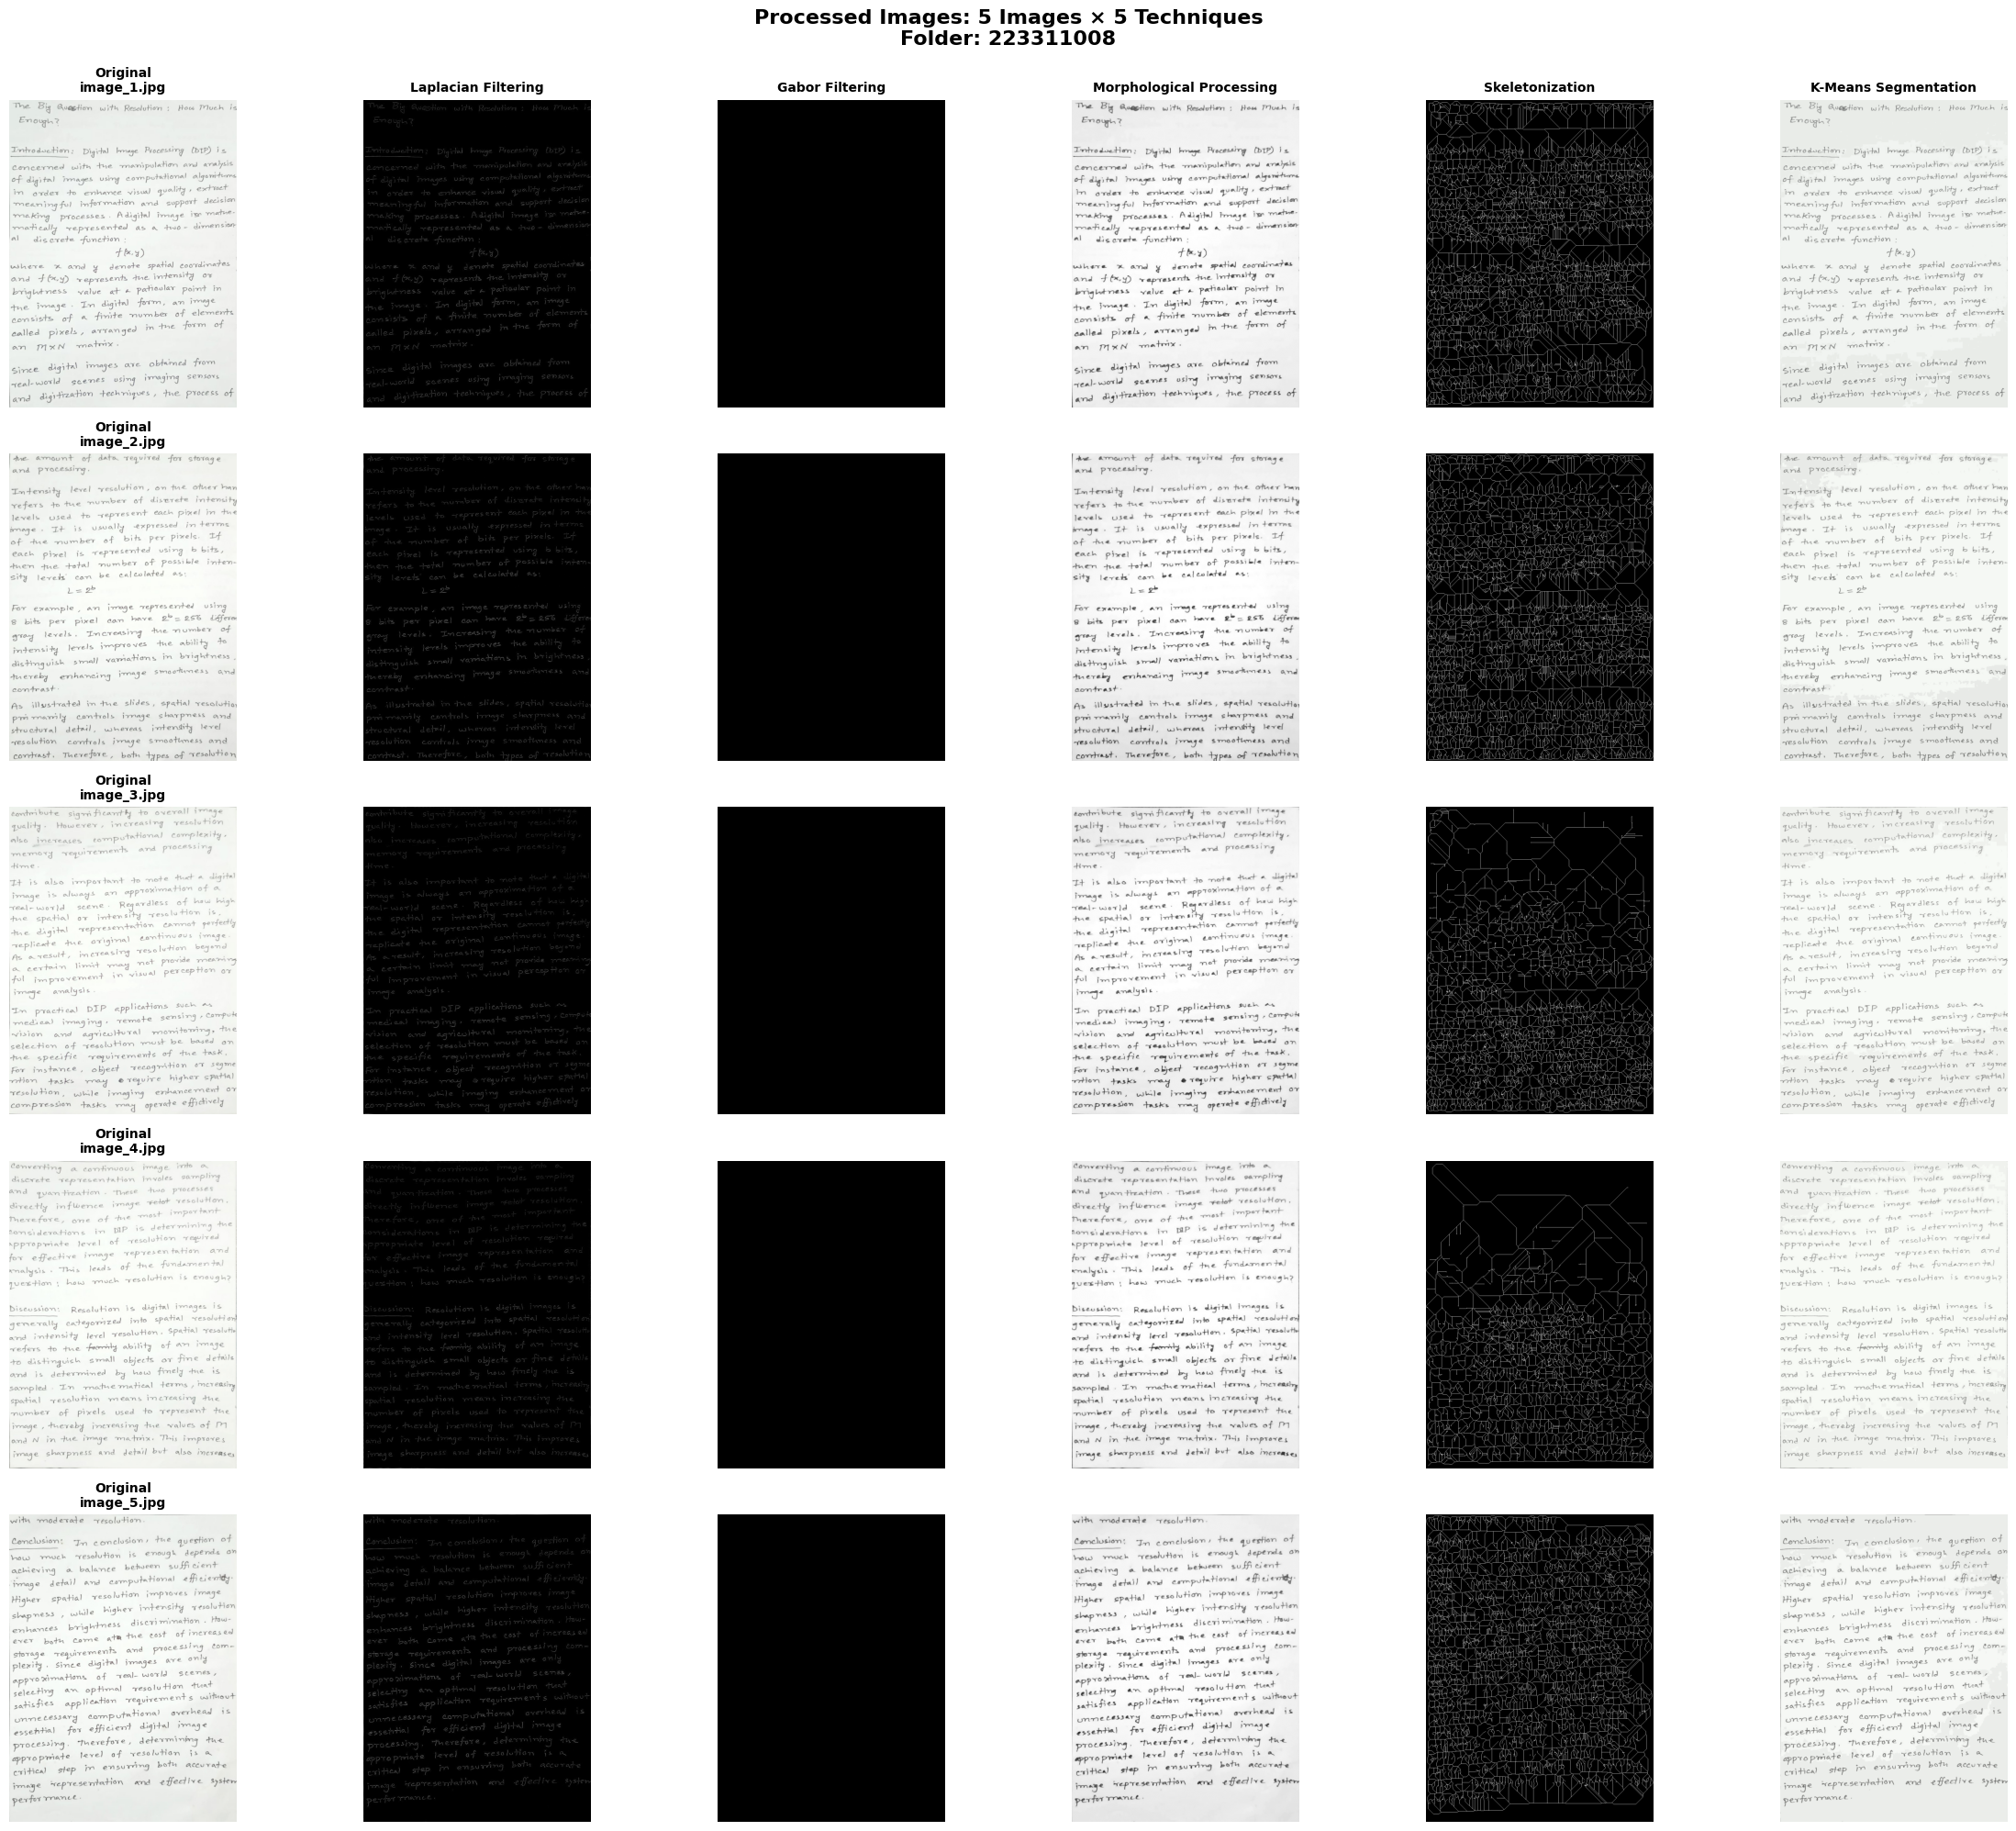

In [8]:
# Select one of the folders with exactly 5 images
selected_folder = folders_with_5_images[8]
folder_path = os.path.join(dataset_path, selected_folder)

# Load all images from the folder
original_images_list = []
image_names = []
img_files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg', '.heic', '.gif', '.bmp'))])

for img_file in img_files:
    img_path = os.path.join(folder_path, img_file)
    img = cv2.imread(img_path)
    if img is not None:
        original_images_list.append(img)
        image_names.append(img_file)

# Display all processed images in a dynamic grid
fig, axes = plt.subplots(len(original_images_list), len(selected_techniques) + 1, figsize=(24, 20))

# For each original image
for img_idx, original_img in enumerate(original_images_list):
    # Show original image in first column
    original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    axes[img_idx, 0].imshow(original_img_rgb)
    axes[img_idx, 0].set_title(f'Original\n{image_names[img_idx]}', fontweight='bold', fontsize=10)
    axes[img_idx, 0].axis('off')
    
    # Apply each technique to this image
    for tech_idx, technique_name in enumerate(selected_techniques):
        technique_func = technique_functions[technique_name]
        processed = technique_func(original_img)
        
        # Display processed image
        if len(processed.shape) == 3:  # Color image
            processed_rgb = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)
            axes[img_idx, tech_idx + 1].imshow(processed_rgb)
        else:  # Grayscale image
            axes[img_idx, tech_idx + 1].imshow(processed, cmap='gray')
        
        # Add title only for first row
        if img_idx == 0:
            axes[img_idx, tech_idx + 1].set_title(technique_name, fontweight='bold', fontsize=10)
        
        axes[img_idx, tech_idx + 1].axis('off')

fig.suptitle(f'Processed Images: {len(original_images_list)} Images × {len(selected_techniques)} Techniques\nFolder: {selected_folder}', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Image Augmentation
Augment processed images using 4 techniques to generate the full final dataset

In [9]:
from scipy import ndimage

# Define augmentation techniques
augmentation_techniques = {
    'Random Rotation': 'random_rotation',
    'Random Horizontal Translation': 'random_translation',
    'Gaussian Noise Injection': 'gaussian_noise',
    'Random Sharpness Adjustment': 'random_sharpness',
    'Elastic Distortion': 'elastic_distortion'
}

# Students select 4 augmentations
selected_augmentations = ['Random Rotation', 'Random Horizontal Translation', 
                          'Gaussian Noise Injection', 'Elastic Distortion']

# Augmentation functions
def apply_random_rotation(img):
    """Apply random rotation"""
    angle = np.random.randint(-15, 16)
    if len(img.shape) == 3:
        return ndimage.rotate(img, angle, axes=(0, 1), reshape=False).astype(np.uint8)
    else:
        return ndimage.rotate(img, angle, reshape=False).astype(np.uint8)

def apply_random_translation(img):
    """Apply random horizontal translation"""
    shift = np.random.randint(-10, 11)
    if len(img.shape) == 3:
        return ndimage.shift(img, (0, shift, 0), mode='constant', cval=0).astype(np.uint8)
    else:
        return ndimage.shift(img, shift, mode='constant', cval=0).astype(np.uint8)

def apply_gaussian_noise(img):
    """Apply Gaussian noise injection"""
    noise = np.random.normal(0, 25, img.shape)
    noisy_img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return noisy_img

def apply_random_sharpness(img):
    """Apply random sharpness adjustment"""
    # Create sharpening kernel
    kernel = np.array([[-1, -1, -1],
                       [-1,  9, -1],
                       [-1, -1, -1]]) / np.random.uniform(0.5, 1.5)
    
    if len(img.shape) == 3:
        # Apply to each channel
        sharpened = cv2.filter2D(img, -1, kernel)
    else:
        sharpened = cv2.filter2D(img, -1, kernel)
    
    return np.clip(sharpened, 0, 255).astype(np.uint8)

def apply_elastic_distortion(img):
    """Apply elastic distortion"""
    alpha = 30
    sigma = 5
    random_state = np.random.RandomState()
    
    if len(img.shape) == 3:
        h, w, c = img.shape
    else:
        h, w = img.shape
        c = 1
    
    # Generate random displacement fields
    dx = random_state.randn(h, w) * sigma
    dy = random_state.randn(h, w) * sigma
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    
    # Apply elastic distortion
    indices = np.reshape(y + dy * alpha, (-1, 1)), np.reshape(x + dx * alpha, (-1, 1))
    
    if len(img.shape) == 3:
        distorted = np.zeros_like(img)
        for channel in range(c):
            distorted[:,:,channel] = ndimage.map_coordinates(img[:,:,channel], indices, order=1, cval=0).reshape(h, w)
    else:
        distorted = ndimage.map_coordinates(img, indices, order=1, cval=0).reshape(h, w)
    
    return distorted.astype(np.uint8)

# Map augmentation names to functions
augmentation_functions = {
    'Random Rotation': apply_random_rotation,
    'Random Horizontal Translation': apply_random_translation,
    'Gaussian Noise Injection': apply_gaussian_noise,
    'Random Sharpness Adjustment': apply_random_sharpness,
    'Elastic Distortion': apply_elastic_distortion
}
print(f"Selected augmentations: {len(selected_augmentations)}")

Selected augmentations: 4


## Apply Augmentations to 25 Processed Images

In [10]:
# Generate 25 processed images and apply 4 augmentation
print("APPLYING AUGMENTATIONS TO PROCESSED IMAGES".center(70))

# Generate 25 processed images from 5 original × 5 techniques
print("\n[STEP 1] Generating 25 processed images...")
processed_images_list = []
processed_image_info = []

for img_idx, original_img in enumerate(original_images_list):
    for tech_idx, technique_name in enumerate(selected_techniques):
        technique_func = technique_functions[technique_name]
        processed = technique_func(original_img)
        processed_images_list.append(processed)
        processed_image_info.append({
            'original': image_names[img_idx],
            'technique': technique_name,
            'index': len(processed_images_list) - 1
        })

print(f"Generated {len(processed_images_list)} processed images")

# Apply 4 augmentations to each processed image
print("\n[STEP 2] Applying {0} augmentations to each processed image...".format(len(selected_augmentations)))
augmented_images_list = []
augmentation_info = []

for proc_idx, processed_img in enumerate(processed_images_list):
    original_info = processed_image_info[proc_idx]
    
    for aug_idx, augmentation_name in enumerate(selected_augmentations):
        aug_func = augmentation_functions[augmentation_name]
        try:
            augmented = aug_func(processed_img)
            augmented_images_list.append(augmented)
            augmentation_info.append({
                'original': original_info['original'],
                'technique': original_info['technique'],
                'augmentation': augmentation_name,
                'index': len(augmented_images_list) - 1
            })
        except Exception as e:
            print(f"   Error in {augmentation_name}: {str(e)[:50]}")

print(f"Generated {len(augmented_images_list)} augmented images")

# Summary
print("\n")
print(f"PROCESSING COMPLETE")
print(f"  • Processed images: {len(processed_images_list)} ({len(original_images_list)} × {len(selected_techniques)})")
print(f"  • Augmented images: {len(augmented_images_list)} ({len(processed_images_list)} × {len(selected_augmentations)})")
print(f"  • Total dataset: {len(augmented_images_list)} images ready")

              APPLYING AUGMENTATIONS TO PROCESSED IMAGES              

[STEP 1] Generating 25 processed images...
Generated 25 processed images

[STEP 2] Applying 4 augmentations to each processed image...
Generated 100 augmented images


PROCESSING COMPLETE
  • Processed images: 25 (5 × 5)
  • Augmented images: 100 (25 × 4)
  • Total dataset: 100 images ready


## Apply Augmentations to Processed Images

In [24]:
# Generate processed images and apply 4 augmentations
print("APPLYING AUGMENTATIONS TO PROCESSED IMAGES".center(70))

# Generate processed images from the full dataset × selected techniques
print("\n[STEP 1] Generating processed images...")
processed_images_list = []
processed_image_info = []

for img_idx, original_img in enumerate(original_images_list):
    for tech_idx, technique_name in enumerate(selected_techniques):
        technique_func = technique_functions[technique_name]
        processed = technique_func(original_img)
        processed_images_list.append(processed)
        processed_image_info.append({
            'original': f"{image_folders[img_idx]}/{image_names[img_idx]}",
            'technique': technique_name,
            'index': len(processed_images_list) - 1
        })

print(f"Generated {len(processed_images_list)} processed images")

# Apply 4 augmentations to each processed image
print("\n[STEP 2] Applying {0} augmentations to each processed image...".format(len(selected_augmentations)))
augmented_images_list = []
augmentation_info = []

for proc_idx, processed_img in enumerate(processed_images_list):
    original_info = processed_image_info[proc_idx]
    
    for aug_idx, augmentation_name in enumerate(selected_augmentations):
        aug_func = augmentation_functions[augmentation_name]
        try:
            augmented = aug_func(processed_img)
            augmented_images_list.append(augmented)
            augmentation_info.append({
                'original': original_info['original'],
                'technique': original_info['technique'],
                'augmentation': augmentation_name,
                'index': len(augmented_images_list) - 1
            })
        except Exception as e:
            print(f"   Error in {augmentation_name}: {str(e)[:50]}")

print(f"Generated {len(augmented_images_list)} augmented images")

# Summary
print("\n")
print(f"PROCESSING COMPLETE")
print(f"  • Processed images: {len(processed_images_list)} ({len(original_images_list)} × {len(selected_techniques)})")
print(f"  • Augmented images: {len(augmented_images_list)} ({len(processed_images_list)} × {len(selected_augmentations)})")
print(f"  • Total dataset: {len(augmented_images_list)} images ready")

              APPLYING AUGMENTATIONS TO PROCESSED IMAGES              

[STEP 1] Generating processed images...
Generated 1155 processed images

[STEP 2] Applying 4 augmentations to each processed image...


KeyboardInterrupt: 

# Model Development

## Data Preparation for Model Training

In [12]:
# import os
# import cv2
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from tqdm import tqdm
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# from sklearn.svm import SVC
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from xgboost import XGBClassifier

# import tensorflow as tf
# from tensorflow.keras.utils import to_categorical
# from tensorflow.keras.applications import (
#     ResNet50,
#     EfficientNetV2B3,
#     InceptionV3,
#     ConvNeXtTiny
# )
# from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
# from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
# from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as efficientnet_preprocess
# from tensorflow.keras.applications.convnext import preprocess_input as convnext_preprocess

# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Dense
# from tensorflow.keras.layers import GlobalAveragePooling2D
# from tensorflow.keras.layers import Dropout
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping

In [13]:
# DATASET_PATH = r"dataset"

In [14]:
# IMG_SIZE = 224

# images = []
# labels = []

# writers = os.listdir(DATASET_PATH)

# for writer in tqdm(writers):

#     writer_path = os.path.join(DATASET_PATH, writer)

#     if not os.path.isdir(writer_path):
#         continue

#     for image_name in os.listdir(writer_path):

#         image_path = os.path.join(writer_path, image_name)

#         image = cv2.imread(image_path)

#         if image is None:
#             continue

#         image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#         image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

#         images.append(image)
#         labels.append(writer)

# images = np.array(images)
# labels = np.array(labels)

# print("Images Shape:", images.shape)
# print("Labels Shape:", labels.shape)

100%|██████████| 47/47 [00:09<00:00,  5.12it/s]

Images Shape: (234, 224, 224, 3)
Labels Shape: (234,)


In [15]:
# label_encoder = LabelEncoder()
# encoded_labels = label_encoder.fit_transform(labels)

# num_classes = len(np.unique(encoded_labels))

# print("Total Writers:", num_classes)

Total Writers: 46


In [16]:
# X_train, X_test, y_train, y_test = train_test_split(
#     images,
#     encoded_labels,
#     test_size=0.2,
#     random_state=42,
#     stratify=encoded_labels
# )

# print(X_train.shape)
# print(X_test.shape)

(187, 224, 224, 3)
(47, 224, 224, 3)


# OPTION A: MACHINE LEARNING MODELS

In [17]:
# X_train_ml = X_train.reshape(len(X_train), -1)
# X_test_ml = X_test.reshape(len(X_test), -1)

# print(X_train_ml.shape)

(187, 150528)


In [18]:
# svm_model = SVC(kernel='rbf')

# svm_model.fit(X_train_ml, y_train)

# svm_predictions = svm_model.predict(X_test_ml)

# svm_accuracy = accuracy_score(y_test, svm_predictions)

# print("SVM Accuracy:", svm_accuracy)
# print(classification_report(y_test, svm_predictions))

KeyboardInterrupt: 

In [ ]:
# rf_model = RandomForestClassifier(
#     n_estimators=100,
#     random_state=42,
#     n_jobs=-1
# )

# rf_model.fit(X_train_ml, y_train)

# rf_predictions = rf_model.predict(X_test_ml)

# rf_accuracy = accuracy_score(y_test, rf_predictions)

# print("Random Forest Accuracy:", rf_accuracy)
# print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.7446808510638298
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       0.00      0.00      0.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       0.50      1.00      0.67         1
          11       0.00      0.00      0.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         2
          16       0.00      0.00     

e:\Important\Skills\deep-writer-identification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Important\Skills\deep-writer-identification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Important\Skills\deep-writer-identification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

In [ ]:
# knn_model = KNeighborsClassifier(n_neighbors=5)

# knn_model.fit(X_train_ml, y_train)

# knn_predictions = knn_model.predict(X_test_ml)

# knn_accuracy = accuracy_score(y_test, knn_predictions)

# print("k-NN Accuracy:", knn_accuracy)
# print(classification_report(y_test, knn_predictions))

k-NN Accuracy: 0.19148936170212766
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       1.00      1.00      1.00         1
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         1
           7       1.00      1.00      1.00         1
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         1
          12       0.50      1.00      0.67         1
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         2
          16       0.00      0.00      0.00   

e:\Important\Skills\deep-writer-identification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Important\Skills\deep-writer-identification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Important\Skills\deep-writer-identification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [ ]:
# xgb_model = XGBClassifier(
#     objective='multi:softmax',
#     num_class=num_classes,
#     eval_metric='mlogloss',
#     random_state=42
# )

# xgb_model.fit(X_train_ml, y_train)

# xgb_predictions = xgb_model.predict(X_test_ml)

# xgb_accuracy = accuracy_score(y_test, xgb_predictions)

# print("XGBoost Accuracy:", xgb_accuracy)
# print(classification_report(y_test, xgb_predictions))

# OPTION B: PRETRAINED CNN MODELS

In [ ]:
# y_train_cat = to_categorical(y_train, num_classes)
# y_test_cat = to_categorical(y_test, num_classes)

In [ ]:
# EPOCHS = 20
# BATCH_SIZE = 32

# callbacks = [
#     EarlyStopping(
#         monitor='val_loss',
#         patience=5,
#         restore_best_weights=True
#     )
# ]


# def build_model(base_model, preprocess_function):

#     inputs = tf.keras.Input(shape=(224, 224, 3))

#     x = preprocess_function(inputs)

#     x = base_model(x, training=False)

#     x = GlobalAveragePooling2D()(x)

#     x = Dense(512, activation='relu')(x)

#     x = Dropout(0.5)(x)

#     outputs = Dense(num_classes, activation='softmax')(x)

#     model = Model(inputs, outputs)

#     model.compile(
#         optimizer=Adam(learning_rate=0.0001),
#         loss='categorical_crossentropy',
#         metrics=['accuracy']
#     )

#     return model

In [ ]:
# base_resnet = ResNet50(
#     weights='imagenet',
#     include_top=False,
#     input_shape=(224, 224, 3)
# )

# base_resnet.trainable = False

# resnet_model = build_model(base_resnet, resnet_preprocess)

# history_resnet = resnet_model.fit(
#     X_train,
#     y_train_cat,
#     validation_data=(X_test, y_test_cat),
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     callbacks=callbacks
# )

# resnet_loss, resnet_accuracy = resnet_model.evaluate(X_test, y_test_cat)

# print("ResNet50 Accuracy:", resnet_accuracy)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.0374 - loss: 4.7565 - val_accuracy: 0.0851 - val_loss: 3.7476
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.0588 - loss: 4.0460 - val_accuracy: 0.1064 - val_loss: 3.4861
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.1070 - loss: 3.8926 - val_accuracy: 0.1915 - val_loss: 3.2874
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.1176 - loss: 3.5018 - val_accuracy: 0.2340 - val_loss: 3.1320
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.1444 - loss: 3.5597 - val_accuracy: 0.2766 - val_loss: 2.9948
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2299 - loss: 3.0553 - val_accuracy: 0.3404 - val_loss: 2.8714
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2727 - loss: 2.8982 - val_accuracy: 0.4043 - val_loss: 2.7505
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.3476 - loss: 2.6368 - val

In [ ]:
# base_efficientnet = EfficientNetV2B3(
#     weights='imagenet',
#     include_top=False,
#     input_shape=(224, 224, 3)
# )

# base_efficientnet.trainable = False

# efficientnet_model = build_model(
#     base_efficientnet,
#     efficientnet_preprocess
# )

# history_efficientnet = efficientnet_model.fit(
#     X_train,
#     y_train_cat,
#     validation_data=(X_test, y_test_cat),
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     callbacks=callbacks
# )

# efficientnet_loss, efficientnet_accuracy = efficientnet_model.evaluate(
#     X_test,
#     y_test_cat
# )

# print("EfficientNetV2B3 Accuracy:", efficientnet_accuracy)

52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.0321 - loss: 3.9018 - val_accuracy: 0.0426 - val_loss: 3.7677
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 656ms/step - accuracy: 0.0642 - loss: 3.7901 - val_accuracy: 0.0638 - val_loss: 3.6908
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 581ms/step - accuracy: 0.0749 - loss: 3.7184 - val_accuracy: 0.1064 - val_loss: 3.6257
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 607ms/step - accuracy: 0.1070 - loss: 3.6259 - val_accuracy: 0.1064 - val_loss: 3.5662
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 703ms/step - accuracy: 0.1176 - loss: 3.5611 - val_accuracy: 0.1702 - val_loss: 3.5145
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 326ms/step - accuracy: 0.0426 - loss: 3.7677
EfficientNetV2B3 Accuracy: 0.042553190141916275


In [ ]:
# base_inception = InceptionV3(
#     weights='imagenet',
#     include_top=False,
#     input_shape=(224, 224, 3)
# )

# base_inception.trainable = False

# inception_model = build_model(
#     base_inception,
#     inception_preprocess
# )

# history_inception = inception_model.fit(
#     X_train,
#     y_train_cat,
#     validation_data=(X_test, y_test_cat),
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     callbacks=callbacks
# )

# inception_loss, inception_accuracy = inception_model.evaluate(
#     X_test,
#     y_test_cat
# )

# print("InceptionV3 Accuracy:", inception_accuracy)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 974ms/step - accuracy: 0.0053 - loss: 4.1229 - val_accuracy: 0.0213 - val_loss: 3.8232
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 601ms/step - accuracy: 0.0321 - loss: 3.8271 - val_accuracy: 0.0638 - val_loss: 3.6997
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 660ms/step - accuracy: 0.0909 - loss: 3.6167 - val_accuracy: 0.0851 - val_loss: 3.6158
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 635ms/step - accuracy: 0.1123 - loss: 3.4975 - val_accuracy: 0.1489 - val_loss: 3.5369
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 610ms/step - accuracy: 0.1497 - loss: 3.3732 - val_accuracy: 0.1915 - val_loss: 3.4645
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step - accuracy: 0.0213 - loss: 3.8232
InceptionV3 Accuracy: 0.021276595070958138


In [ ]:
# from tensorflow.keras.applications import InceptionResNetV2

# base_google = InceptionResNetV2(
#     weights='imagenet',
#     include_top=False,
#     input_shape=(224, 224, 3)
# )

# base_google.trainable = False

# google_model = build_model(
#     base_google,
#     inception_preprocess
# )

# history_google = google_model.fit(
#     X_train,
#     y_train_cat,
#     validation_data=(X_test, y_test_cat),
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     callbacks=callbacks
# )

# google_loss, google_accuracy = google_model.evaluate(
#     X_test,
#     y_test_cat
# )

# print("GoogLeNet Style Accuracy:", google_accuracy)


219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 22s 0us/step
Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.0107 - loss: 4.1942 - val_accuracy: 0.1489 - val_loss: 3.7470
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.0856 - loss: 3.8364 - val_accuracy: 0.1277 - val_loss: 3.5896
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.1230 - loss: 3.5970 - val_accuracy: 0.1489 - val_loss: 3.4764
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.1551 - loss: 3.4947 - val_accuracy: 0.1489 - val_loss: 3.3845
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.1444 - loss: 3.3832 - val_accuracy: 0.1915 - val_loss: 3.3189
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 620ms/step - accuracy: 0.1489 - loss: 3.7470
GoogLeNet Style Accuracy: 0.1489361673593521


In [ ]:
# base_convnext = ConvNeXtTiny(
#     weights='imagenet',
#     include_top=False,
#     input_shape=(224, 224, 3)
# )

# base_convnext.trainable = False

# convnext_model = build_model(
#     base_convnext,
#     convnext_preprocess
# )

# history_convnext = convnext_model.fit(
#     X_train,
#     y_train_cat,
#     validation_data=(X_test, y_test_cat),
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     callbacks=callbacks
# )

# convnext_loss, convnext_accuracy = convnext_model.evaluate(
#     X_test,
#     y_test_cat
# )

# print("ConvNeXtTiny Accuracy:", convnext_accuracy)

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 37s 6s/step - accuracy: 0.0053 - loss: 4.4004 - val_accuracy: 0.0213 - val_loss: 4.0571
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 29s 5s/step - accuracy: 0.0481 - loss: 4.1592 - val_accuracy: 0.0213 - val_loss: 3.9300
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 29s 5s/step - accuracy: 0.0267 - loss: 4.0257 - val_accuracy: 0.0426 - val_loss: 3.8277
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 29s 5s/step - accuracy: 0.0481 - loss: 3.9923 - val_accuracy: 0.0638 - val_loss: 3.7488
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 28s 5s/step - accuracy: 0.0963 - loss: 3.7481 - val_accuracy: 0.0638 - val_loss: 3.6768
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.0213 - loss: 4.0571
ConvNeXtTiny Accuracy: 0.021276595070958138


In [ ]:
# results = {
#     'SVM': svm_accuracy,
#     'Random Forest': rf_accuracy,
#     'k-NN': knn_accuracy,
#     # 'XGBoost': xgb_accuracy,
#     'ResNet50': resnet_accuracy,
#     'EfficientNetV2B3': efficientnet_accuracy,
#     'InceptionV3': inception_accuracy,
#     'GoogLeNet Style': google_accuracy,
#     'ConvNeXtTiny': convnext_accuracy
# }

# results_df = pd.DataFrame(
#     list(results.items()),
#     columns=['Model', 'Accuracy']
# )

# print(results_df)

              Model  Accuracy
0               SVM  0.319149
1     Random Forest  0.744681
2              k-NN  0.191489
3          ResNet50  0.659574
4  EfficientNetV2B3  0.042553
5       InceptionV3  0.021277
6   GoogLeNet Style  0.148936
7      ConvNeXtTiny  0.021277


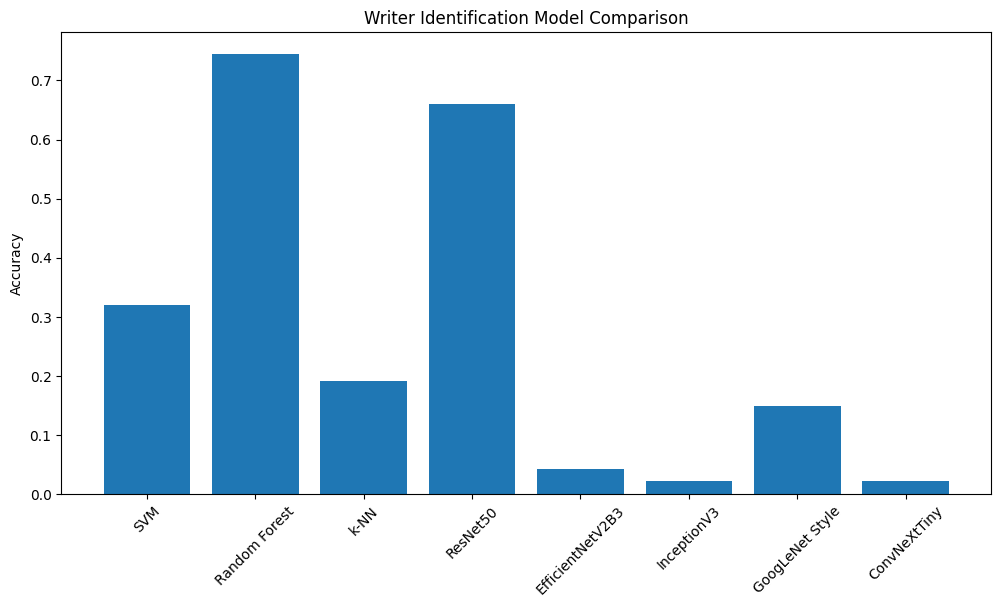

In [ ]:
# plt.figure(figsize=(12,6))

# plt.bar(results_df['Model'], results_df['Accuracy'])

# plt.xticks(rotation=45)
# plt.ylabel('Accuracy')
# plt.title('Writer Identification Model Comparison')

# plt.show()